# OpenVINO Physical AI, Intel Robotics

### Minimal code to run a Pi0.5 Simulation only

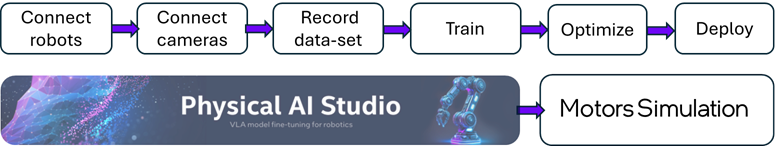

## 1) Install OpenVINO Physical AI

First, we need to install OpenVINO Physical AI runtime and Physical AI Studio training library.

In [ ]:
from pathlib import Path

requirements_file = Path("requirements.txt")
if not requirements_file.exists():
    requirements_file = Path("notebooks/requirements.txt")

if not Path("physicalai").exists():
    !git clone --depth 1 https://github.com/openvinotoolkit/physicalai.git
if not Path("physical-ai-studio").exists():
    !git clone --depth 1 https://github.com/open-edge-platform/physical-ai-studio.git

%pip install -q --extra-index-url https://download.pytorch.org/whl/cpu -r {requirements_file}
%pip install -q -e physicalai
%pip install -q -e "./physical-ai-studio/library[cpu]"


## 2) Configure the Notebook

Typically, you will need dataset created using teleoperation. To simplify testing the workflow, in this example, we will just use a pre-created dataset and a fine tuned and optimized model from the HuggingFace repository

DATASET_REPO_ID is a data set repository on HuggingFace, created using teleoperation (either using Physical AI Studio or LeRobot)
MODEL_REPO_ID   is a fine tuned and optimized Pi0.5 model on this specific dataset

Feel free to replace with your repository, or your local model/dataset by overrideing these environment variables:
- `PHYSICALAI_PI05_EXPORT_DIR`
- `PHYSICALAI_PI05_REPLAY_DATASET`
- `PHYSICALAI_PI05_REPLAY_EPISODE`
- `PHYSICALAI_PI05_TASK`

In [ ]:

# ============================================================
# 🔴 USER PARAMETERS — Edit these before running  🔧
#
#  Initializing model and dataset paths
# ============================================================

MODEL_REPO_ID = "eugene123tw/pi05-pick-place-purple-cube"
DATASET_REPO_ID = "gtamir/pick-place-purple-cube"
DATASET_NAME = "pick-place-purple-cube"



from pathlib import Path
import os
import sys

import openvino as ov
import openvino_tokenizers  # Registers tokenizer custom ops used by tokenizer.xml.
from IPython.display import display

WORKSPACE = Path.cwd().resolve()
sys.path.append(str((WORKSPACE / "notebooks").resolve()))

from physicalai_pi05_helper import (  
    benchmark_with_fallback,
    download_pi05_package,
    prepare_replay_episode,
    run_replay_visualization,
)

ROOT = WORKSPACE / "physicalai"
if ROOT.exists():
    os.chdir(ROOT)

TASK_TEXT = os.environ.get("PHYSICALAI_PI05_TASK", "pick-place-purple-cube")
ASSETS_DIR = Path(os.environ.get("PHYSICALAI_ASSETS_DIR", WORKSPACE / "physicalai_assets")).resolve()

MODEL_DIR = Path(os.environ["PHYSICALAI_PI05_EXPORT_DIR"]).resolve() if os.environ.get("PHYSICALAI_PI05_EXPORT_DIR") else None
REPLAY_DATASET_DIR = Path(os.environ["PHYSICALAI_PI05_REPLAY_DATASET"]).resolve() if os.environ.get("PHYSICALAI_PI05_REPLAY_DATASET") else None
REPLAY_EPISODE_ID = int(os.environ.get("PHYSICALAI_PI05_REPLAY_EPISODE", "0"))
CACHE_DIR = ROOT / "exports" / "pi05_pick_place_purple_cube_cache"
VIS_DIR = ROOT / "exports" / "pi05_so101_visualization"

core = ov.Core()
print("OpenVINO:", ov.__version__)
print("Available devices:", core.available_devices)
print("Task:", TASK_TEXT)


## 3) Get the Pi0.5 OpenVINO Policy Package

A PhysicalAI policy package contains the OpenVINO intermediate representation files ( model.xml, model.bin ), tokenizer artifacts, `manifest.json`, and processor metadata. 


In [ ]:
MODEL_DIR = download_pi05_package(MODEL_REPO_ID, ASSETS_DIR, MODEL_DIR)
print("[DONE] PhysicalAI OpenVINO package is ready.")

## 4) Prepare One Replay Episode

For a fast validation pass, the notebook downloads dataset metadata plus one episode parquet and the two corresponding videos. This is enough to build the same observation dictionary used by Pi0.5 deployment. This is an important step before testing the model on the dataset.


In [ ]:
replay = prepare_replay_episode(
    repo_id=DATASET_REPO_ID,
    dataset_name=DATASET_NAME,
    assets_dir=ASSETS_DIR,
    episode_id=REPLAY_EPISODE_ID,
    dataset_dir=REPLAY_DATASET_DIR,
)

print(f"[DONE] Replay episode {replay.episode_id}: {len(replay.episode_df)} frames at {replay.fps:.1f} FPS")


## 5) Select an OpenVINO Device

This section looks for a compatible GPU with OpenVINO optimized model and targets the device, with a fallback option to run the policy on CPU.

In [ ]:
import ipywidgets as widgets

device_options = list(core.available_devices)
default_device = "GPU" if "GPU" in device_options else "CPU"
TARGET_DEVICE = widgets.Dropdown(
    options=device_options,
    value=default_device if default_device in device_options else device_options[0],
    description="Device:",
)
display(TARGET_DEVICE)


## 6) Load and Benchmark with PhysicalAI Runtime

`InferenceModel.load()` reads the PhysicalAI policy package, selects the OpenVINO backend, applies preprocessors/postprocessors from the manifest, and exposes `predict_action_chunk()` plus `select_action()` for deployment.


In [ ]:
physicalai_model, selected_result = benchmark_with_fallback(
    model_dir=MODEL_DIR,
    replay=replay,
    task=TASK_TEXT,
    device=TARGET_DEVICE.value,
    cache_dir=CACHE_DIR,
    runs=5,
)

print("[RESULT] PhysicalAI Pi0.5 OpenVINO deployment")
for key, value in selected_result.items():
    print(f"  {key}: {value}")


## 7) Replay Visualization

This replay is a simulation-style sanity check: it compares Pi0.5 OpenVINO actions with recorded expert actions while showing both camera views. <br>The MAE is a domain-match signal, not an OpenVINO numerical correctness test.


In [ ]:
replay_result = run_replay_visualization(
    model=physicalai_model,
    model_dir=MODEL_DIR,
    replay=replay,
    task=TASK_TEXT,
    device=selected_result["device"],
    cache_dir=CACHE_DIR,
    output_dir=VIS_DIR,
    max_rendered_frames=120,
    render_stride=3,
)

print("[RESULT] Replay steps:", replay_result["steps"])
print("[RESULT] Rendered frames:", replay_result["rendered_frames"])
print("[RESULT] Avg select_action latency ms:", replay_result["avg_select_action_ms"])
print("[RESULT] Avg MAE vs expert action:", replay_result["avg_mae"])
print("[RESULT] Per-joint MAE:", replay_result["per_joint_mae"])
print("[INTERPRETATION]", replay_result["interpretation"])
print("[DONE] Saved GIF:", replay_result["gif_path"])
display(replay_result["gif"])
